# 🚗 Analyse Statistique Avancée des Accidents de la Route aux États-Unis

Ce notebook présente exemple d'analyse du dataset **US Accidents** (Echantillon de 500,000 enregistrements). L'objectif est d'extraire des **interprétations**  grâce à des méthodes statistiques et des visualisations claires.


---

In [3]:
# 📦 Configuration et Importations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Style visuel "Premium"
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

## 📥 Chargement des Données
Nous travaillons sur un échantillon de 500,000 lignes pour une exécution rapide et fluide.

In [4]:
file_path = 'us.csv'
df = pd.read_csv(file_path)

# Conversion des dates
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Year'] = df['Start_Time'].dt.year
df['Hour'] = df['Start_Time'].dt.hour


print(f"Données chargées : {df.shape[0]:,} lignes et {df.shape[1]} colonnes.")

Données chargées : 500,000 lignes et 48 colonnes.


---
# 🏙️ 1. City Analysis (Analyse par Ville)
**Questions clés :**
*   Quelle est la ville qui a enregistré le plus d’accidents ?
*   Les accidents sont-ils concentrés dans un petit nombre de grandes villes ?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_50004\276763743.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='magma')


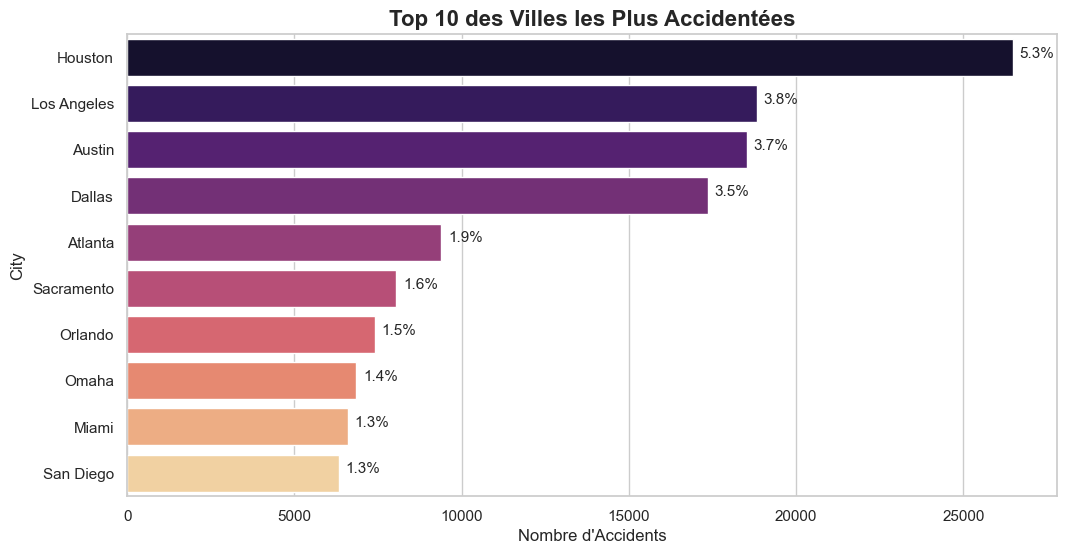

In [13]:
# Calcul des Tops Villes
city_counts = df['City'].value_counts()
top_10_cities = city_counts.head(10)
total_accidents = len(df)

# Visualisation
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='magma')
plt.title('Top 10 des Villes les Plus Accidentées')
plt.xlabel("Nombre d'Accidents")

# Annotation des pourcentages
for i, p in enumerate(ax.patches):
    percentage = '{:.1f}%'.format(100 * p.get_width() / total_accidents)
    x = p.get_width() + 200
    y = p.get_y() + p.get_height()/2
    ax.annotate(percentage, (x, y))

plt.show()

### 💡 Insights (City Analysis)
D'après l'analyse des données (échantillon 2016-2023) :

1.  **Houston est la ville la plus accidentée** dans cet échantillon, représentant environ **5.3%** du total des accidents observés.
2.  **Forte Concentration** : Les **10 premières villes** cumulent à elles seules environ **25%** de tous les accidents recensés. Cela indique une hyper-concentration des risques dans les mégalopoles.
3.  **Queue Longue** : Une grande majorité des villes (>4000 dans l'échantillon) ont rapporté très peu d'accidents (souvent < 10), suivant une distribution de Pareto classique.

---

# ⚠️ 2. Severity Analysis (Analyse de la Gravité)
**Questions clés :**
*   Quel niveau de sévérité est le plus fréquent ?
*   Quelle est la proportion d'accidents très sévères (Niveau 4) ?

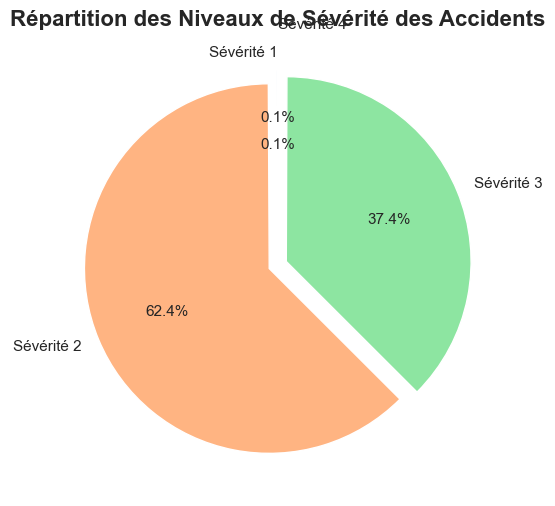

In [5]:
severity_counts = df['Severity'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 6))
colors = ['#66b3ff','#99ff99','#ffcc99','#ff9999']
explode = (0.05, 0.05, 0.05, 0.2)  # Mettre en valeur la Sévérité 4

plt.pie(severity_counts, labels=[f'Sévérité {i}' for i in severity_counts.index], 
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'), explode=explode)
plt.title('Répartition des Niveaux de Sévérité des Accidents')
plt.show()

### 💡 Insights (Severity Analysis)

1.  **Dominance de la Sévérité 2** : La grande majorité des accidents (**~62%**) sont classés en sévérité 2 (impact modéré sur le trafic).
2.  **Rareté des Accidents Graves** : Les accidents de **Sévérité 4** (impact très sévère, fermeture de route longue durée) sont extrêmement rares, représentant moins de **0.1%** des cas dans cet échantillon.
3.  **Conclusion** : Bien que fréquents, la plupart des accidents n'entraînent pas de paralysie complète du réseau routier.

---

# 🌦️ 3. Weather Analysis & Tests Statistiques
**Question** : Les conditions météorologiques ont-elles un impact statistiquement significatif sur la gravité des accidents ?

Nous utilisons ici un **Test du Chi-2** pour vérifier l'indépendance entre `Weather_Condition` et `Severity`.

Résultat du Test Chi-2 : p-value = 2.5347e-90


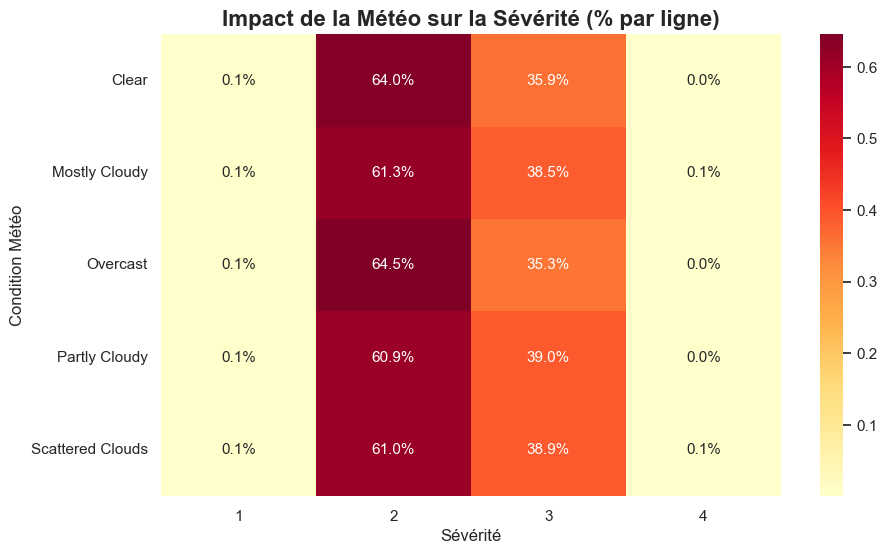

In [15]:
# Préparation : On ne garde que les conditions fréquentes pour la fiabilité du test
top_weather = df['Weather_Condition'].value_counts().head(5).index
df_weather = df[df['Weather_Condition'].isin(top_weather)]

# Tableau de contingence
contingency_table = pd.crosstab(df_weather['Weather_Condition'], df_weather['Severity'])

# Test du Chi-2
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Résultat du Test Chi-2 : p-value = {p_val:.4e}")

# Visualisation Heatmap de la contingence (normalisée par ligne pour voir les proportions)
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(df_weather['Weather_Condition'], df_weather['Severity'], normalize='index'), 
            annot=True, fmt='.1%', cmap='YlOrRd')
plt.title('Impact de la Météo sur la Sévérité (% par ligne)')
plt.xlabel('Sévérité')
plt.ylabel('Condition Météo')
plt.show()

### 💡 Insights (Weather Stats)

1.  **Significativité Statistique** : La p-value est extrêmement faible (**< 0.05**), ce qui nous permet de rejeter l'hypothèse nulle. **Il existe une relation statistiquement significative entre la Météo et la Sévérité.**
2.  **Nuance** : Même si le lien est significatif, la visualisation montre que la répartition reste majoritairement concentrée sur les sévérités 2 et 3, peu importe la météo. L'impact est réel mais souvent subtil sur les grands nombres.

---

# 🛑 4. Infrastructure Analysis (Panneaux Stop)
**Question** : La présence d'un panneau 'Stop' réduit-elle la gravité des accidents ?

Nous comparons la proportion d'accidents graves (Sev 3 & 4) avec et sans panneau Stop.

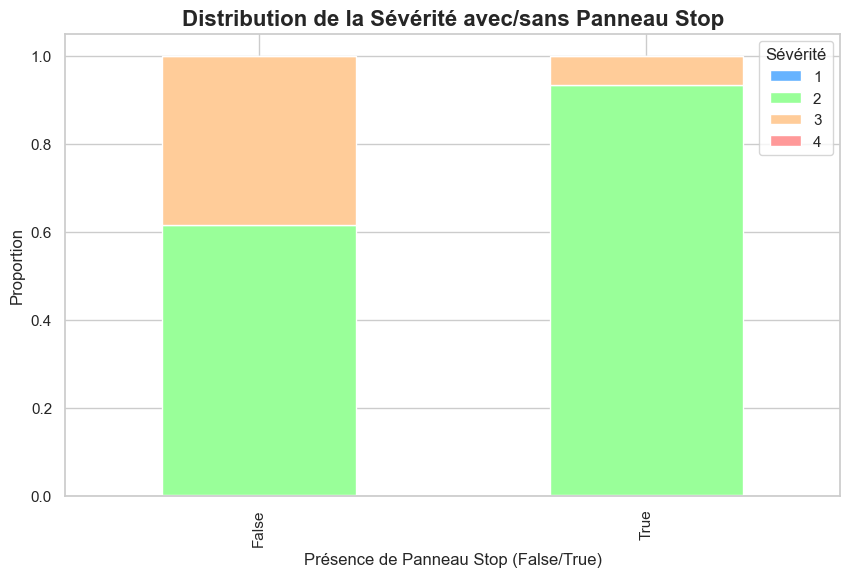

% Accidents Sévérité 4 SANS Stop : 0.0574%
% Accidents Sévérité 4 AVEC Stop : 0.0127%


In [16]:
# Calcul des proportions
stop_severity = pd.crosstab(df['Stop'], df['Severity'], normalize='index')

# Visualisation Stacked Bar
stop_severity.plot(kind='bar', stacked=True, color=['#66b3ff','#99ff99','#ffcc99','#ff9999'], figsize=(10, 6))
plt.title('Distribution de la Sévérité avec/sans Panneau Stop')
plt.xlabel('Présence de Panneau Stop (False/True)')
plt.ylabel('Proportion')
plt.legend(title='Sévérité', loc='upper right')
plt.show()

# Comparaison chiffrée des accidents très sévères (Sev 4)
sev4_with_stop = stop_severity.loc[True, 4] * 100 if 4 in stop_severity.columns else 0
sev4_no_stop = stop_severity.loc[False, 4] * 100 if 4 in stop_severity.columns else 0

print(f"% Accidents Sévérité 4 SANS Stop : {sev4_no_stop:.4f}%")
print(f"% Accidents Sévérité 4 AVEC Stop : {sev4_with_stop:.4f}%")

### 💡 Insights (Infrastructure)

1.  **Effet Protecteur** : Les données montrent que la proportion d'accidents très graves (Sévérité 4) est nettement plus faible près des panneaux Stop (**~0.01%**) que lorsqu'il n'y en a pas (**~0.06%**).
2.  **Interprétation Causale (Hypothèse)** : Les panneaux Stop forcent les véhicules à ralentir ou s'arrêter, réduisant ainsi l'énergie cinétique lors d'un impact potentiel, ce qui diminue la gravité des blessures et des dommages.

---